In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate,
)
from tensorflow.keras.models import Model
from sklearn.calibration import LabelEncoder

In [3]:
df = pd.read_parquet("../datasets/full_train_dataset_with_embeddings.parquet")

In [6]:
df = df.dropna(how="any")

In [4]:
le = LabelEncoder()
df["Zipcode_endcoded"] = le.fit_transform(df["Zip-code"])
df = df.drop(columns=["Zip-code"])

In [7]:
df["original_langage_encoded"] = le.fit_transform(df["original_language"])
df = df.drop(columns=["original_language"])

In [8]:
df["occupation_encoded"] = le.fit_transform(df["Occupation"])
df = df.drop(columns=["Occupation"])

In [9]:
df = pd.get_dummies(
    df,
    columns=["Gender"],
    dtype=np.float32,
)

In [10]:
# feature columns
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult"
    
]
numeric_cols = ["popularity", "vote_average", "vote_count", "original_langage_encoded"]
user_cols = [
    "UserID",
    "Age",
    "occupation_encoded",
    "Zipcode_endcoded",
    "Gender_M",
    "Gender_F",
]

In [11]:
user_vecs = df[user_cols].to_numpy(dtype=np.float32)
item_vecs = df[genre_cols + numeric_cols].to_numpy(dtype=np.float32)
overview_embdeddings_vecs = np.stack(df["embedding"].values).astype(np.float32)
ratings = df["Rating"].to_numpy(dtype=np.float32)

In [12]:
u_train, u_test, e_train, e_test, i_train, i_test, y_train, y_test = train_test_split(
    user_vecs,
    overview_embdeddings_vecs,
    item_vecs,
    ratings,
    test_size=0.2,
    random_state=42,
)

In [14]:
pd.DataFrame(u_train).to_parquet("../datasets/train-test-split/user_train.parquet")
pd.DataFrame(u_test).to_parquet("../datasets/train-test-split/user_test.parquet")

pd.DataFrame(e_train).to_parquet(
    "../datasets/train-test-split/explanation_train.parquet"
)
pd.DataFrame(e_test).to_parquet("../datasets/train-test-split/explanation_test.parquet")

pd.DataFrame(i_train).to_parquet("../datasets/train-test-split/item_train.parquet")
pd.DataFrame(i_test).to_parquet("../datasets/train-test-split/item_test.parquet")

pd.DataFrame(y_train).to_parquet("../datasets/train-test-split/rating_train.parquet")
pd.DataFrame(y_test).to_parquet("../datasets/train-test-split/rating_test.parquet")

In [15]:
n_users = df.UserID.max() + 1  # replace with: df.UserID.max()+1
user_dim = u_train.shape[1]

overview_dim = overview_embdeddings_vecs.shape[1]  # embedding dimension
n_genres = len(genre_cols)  
n_numeric = len(numeric_cols)
movie_dim = n_genres + n_numeric

# ——— Inputs ———
inp_user = Input(shape=(user_dim,), name="user_id")
inp_movie = Input(shape=(movie_dim,), name="movie_feat")
inp_overview = Input(shape=(overview_dim,), name="overview_emb_feat")
# ——— User tower ———
u = Embedding(input_dim=n_users, output_dim=user_dim, name="user_emb")(inp_user)
u = Flatten()(u)
u = Dense(64, activation="relu")(u)
u = Dropout(0.2)(u)

# ——— Movie tower ———
m = Dense(256, activation="relu")(inp_movie)
m = BatchNormalization()(m)
m = Dropout(0.3)(m)
m = Dense(128, activation="relu")(m)
m = Dropout(0.2)(m)

# ——— Overview tower ———
e = Dense(256, activation="relu")(inp_overview)
e = BatchNormalization()(e)
e = Dropout(0.3)(e)
e = Dense(128, activation="relu")(e)
e = Dropout(0.2)(e)

# ——— Combine & head ———
x = Concatenate()([u, m, e])
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

out = Dense(1, name="rating")(x)  # linear activation for regression

In [16]:
model = Model([inp_user, inp_movie, inp_overview], out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movie_feat          │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ overview_emb_feat   │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_id             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │      6,144 │ movie_feat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     98,560 │ overview_emb_fea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 6, 6)      │     36,246 │ user_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 36)        │          0 │ user_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,368 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_2[0][0],  │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    164,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 528,855 (2.02 MB)

 Trainable params: 526,103 (2.01 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [17]:
history = model.fit(
    x=[u_train, i_train, e_train],
    y=y_train,
    batch_size=256,
    epochs=15,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True
        )
    ],
)

Epoch 1/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 4.2958 - root_mean_squared_error: 1.9864 - val_loss: 0.8892 - val_root_mean_squared_error: 0.9430
Epoch 2/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 1.0043 - root_mean_squared_error: 1.0021 - val_loss: 0.8577 - val_root_mean_squared_error: 0.9261
Epoch 3/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 0.9274 - root_mean_squared_error: 0.9630 - val_loss: 0.8365 - val_root_mean_squared_error: 0.9146
Epoch 4/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.8813 - root_mean_squared_error: 0.9388 - val_loss: 0.8292 - val_root_mean_squared_error: 0.9106
Epoch 5/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.8481 - root_mean_squared_error: 0.9209 - val_loss: 0.8141 - val_root_mean_squared_error: 0.9023
Epoch 6/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 0.8312 - root_mean_squared_error: 0.9117 - val_loss: 0.8067 - val_root_mean_squared_error: 0.8981
Epoch 7/15
2412/2412 ━━━━━━━

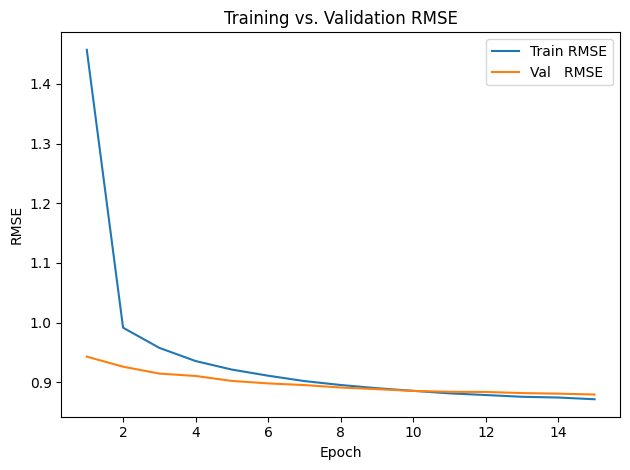

In [18]:
import matplotlib.pyplot as plt


train_rmse = history.history["root_mean_squared_error"]
val_rmse = history.history["val_root_mean_squared_error"]
epochs = range(1, len(train_rmse) + 1)

plt.figure()
plt.plot(epochs, train_rmse, label="Train RMSE")
plt.plot(epochs, val_rmse, label="Val   RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs. Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
train_rmse = history.history["root_mean_squared_error"]
val_rmse = history.history["val_root_mean_squared_error"]
print(f"Final Train RMSE: {train_rmse[-1]:.4f}")
print(f"Final Validation RMSE: {val_rmse[-1]:.4f}")

Final Train RMSE: 0.8716
Final Validation RMSE: 0.8795


In [20]:
model.save("../models/mlp_with_overview/1/model.keras", )

In [21]:
model_json = model.to_json()
with open("../models/mlp_with_overview/1/model_architecture.json", "w") as f:
    f.write(model_json)

In [22]:
model.save_weights("../models/mlp_with_overview/1/model.weights.h5")